__Базовая информация про SQLAlchemy__

__Как устроена алхимия?__

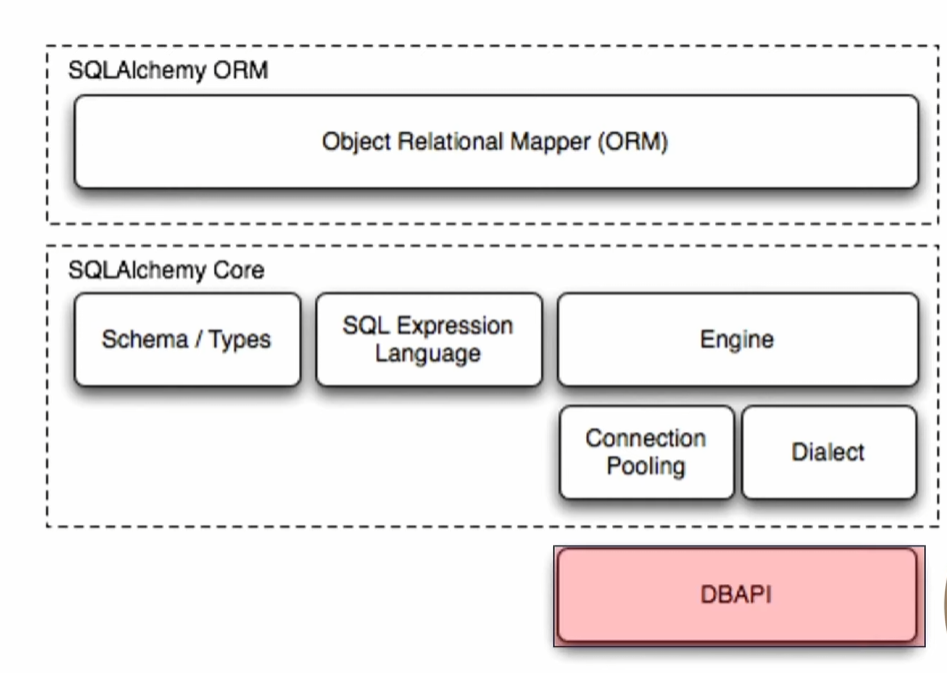

__Подключение к Базе Данных, сырые SQL запросы через engine__

Пример конфигурации БД:

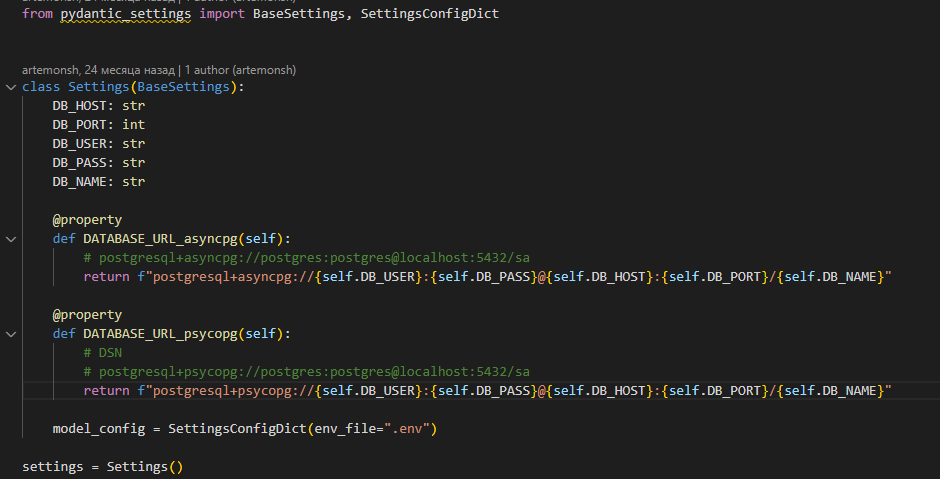

Чтоб подключить к БД нужно создать engine (движок):

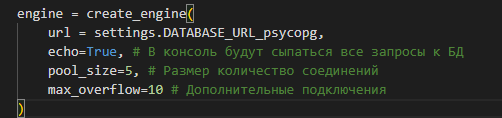

Как только мы создадим и вызовем engine - никакого подключения к базе не будет, нужно все проверить вызовом

Запросы пишутся с контекстным менеджером, чтобы после запроса доступ к БД закрылся.

Алхимия не принимает строки как запросы их всегда нужно оборачивать в text

Пример простого запроса через connect:

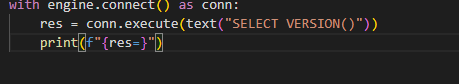

Можно также использовать begin:

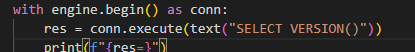

Но используя begin мы будем иметь в конце выполнения commit

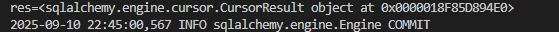

Чтоб получить все данные можно использовать:



он берет данные из оперативки

res.first() возвращает кортеж, чтобы хранить все столбцы 

Когда пишем сырые запросы -> работа алхимия максимально ускоряется (запрос не проходит стадии перехода и дает бафф к времени)

Но можно отходить от сырых запросов и использовать query-билдер

Асинхронный движок можно создать следующим образом:

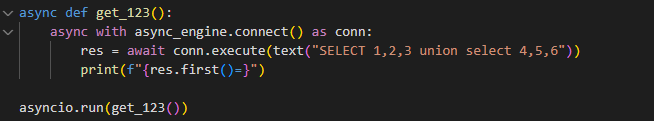

__Создание таблиц и вставка данных через Core__

MetaData - это метаданные, в ней будут храниться данные о всех-всех таблицах, которые мы создадим. Он передается во все таблицы, модели и т.п для миграций



Чтобы создать таблицу нужно:

1. Объявить ее в models.py

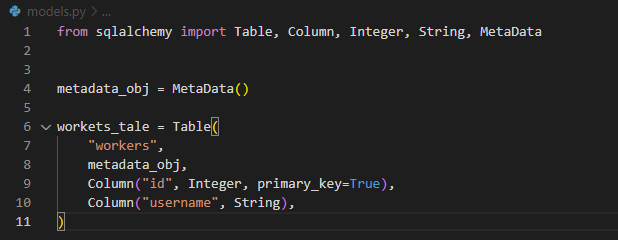

2. Сделать функцию в core которая будет вызывать метод create_allу объекта метадаты

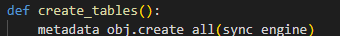

3. Вызвать эту функцию

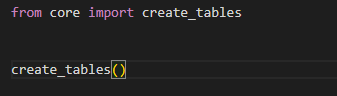

Перепишем создание таблицы:

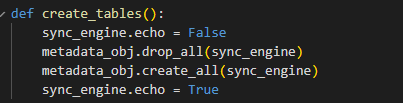

И напишем функцию для вставки:

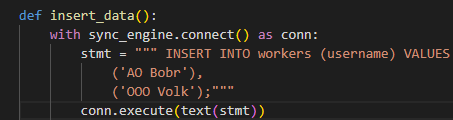

Можно также написать запрос через query-builder (для работы нам нужна таблица)

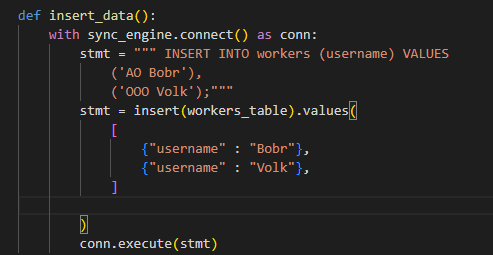

__Session и первые шаги в ORM__

session (сессия) - нужна для транзакций, когда мы входим в сессию мы открываем транзакцию и затем делаем коммити т.д

Перед тем как создавать сессии, нужно определеить некоторые данные.

Чтоб создавать какие-либо классы, нам нужны метаданные - начало всех классов мы возьмем из sqlalchemy.orm _DeclarativeBase_:

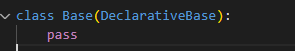

Как определять модели?

Стоит отметить, что при создании модели мы должны импортировать Mapped, mapped_column, чтобы задавать типы данных:



Создадим класс в декларативном стиле:

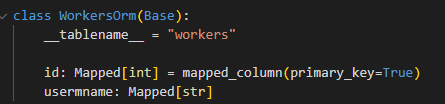

Создадим сессию в database.py:



В файле orm.py определим методы:

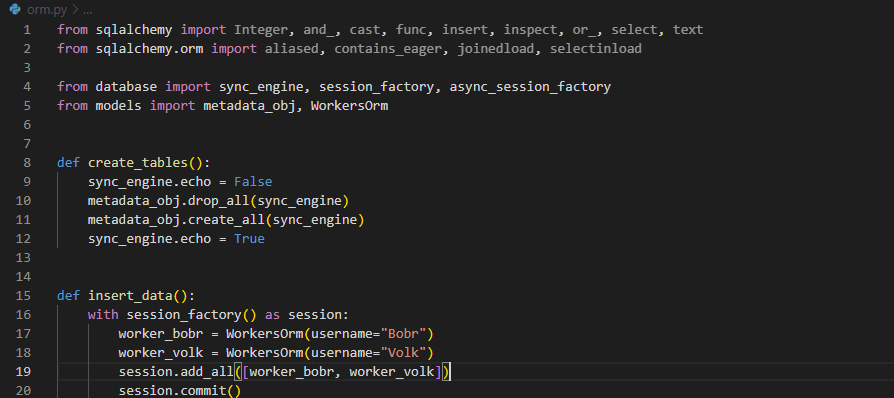

* До этапа коммита - данные в базе не хранятся

И вызовем все в main.py

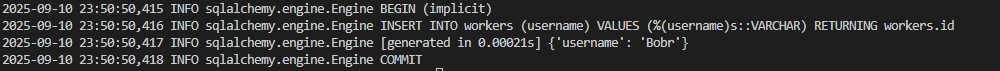

Тот же запрос но асинхронно:

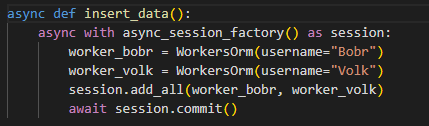

Перед session.add_all() не нужно писать await, так как эта функция никуда не отправляет данные, эт все хранится в ОЗУ



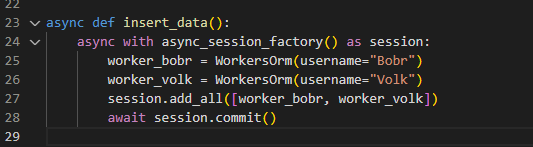

__Создание таблиц через КЛАССЫ - Mapped и mapped_column__

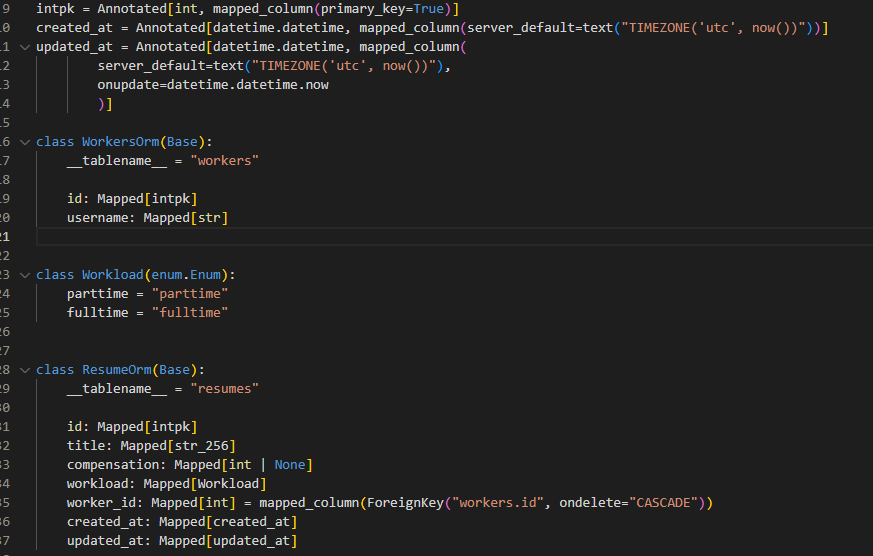

При создании класса:

Можно указать, что поле может быть как nullable, так и инт с помощью:



Чтоб сделать enum-поле необходимо:

1. Создать класс Enum

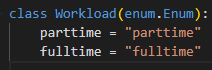

2. Добавит это поле в класс таблицы



Алихимия все сама поймет

Также можно указать внешний ключ:

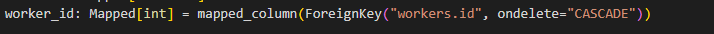

советуется указывать строчным вариантом, так как если привызяывать класс (WokerksOrm.id) придется очень много возиться с импортами.

ondelete используется чтоб указать, что при удалении конкретного wokers удалялись (в нашем случае каскадно) все его резюме

Чтоб задать время:



кроме server_default (где данные задаюся на уровне бд), есть default, где данные задаются на уровне python-приложения:



Чтобы заменить эту повторяющиеся запись:



Мы можем создать аннотацию и дальше ее везде использовать:



Пример чтобы ограничить количество символов:



Вообще рекомендуется в базовом классе создать словарь, где мы будем хранить все эт дело:

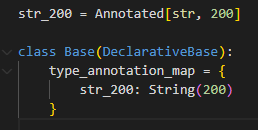

Также стоит отметить, что теперь у нас вся метадата хранится в классе Base

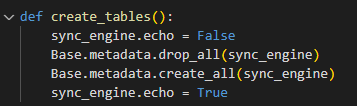